# 03 - Maintenance and reliability EDA (SYNTHETIC)

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30); pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
from og_oip import config
NOTICE = config.SYNTHETIC_NOTICE
print(NOTICE)

All operational, production, financial, maintenance, inventory, sensor and HSE data in this project are synthetic/simulated and created for portfolio demonstration purposes. They do not represent actual operations of a real company.


In [2]:
M = {p.stem: pd.read_csv(p, parse_dates=[c for c in ("date","month") if c in pd.read_csv(p, nrows=0).columns]) for p in config.MARTS_DIR.glob("mart_*.csv")}
wd, fm, es = M["mart_well_daily"], M["mart_field_monthly"], M["mart_equipment_summary"]

In [3]:
from og_oip.analytics import maintenance
maint = pd.read_csv(config.PROCESSED_DIR / "fact_maintenance.csv", parse_dates=["date"])
k = maintenance.kpis(es, maint); k

{'failure_count': 412, 'total_maintenance_events': 1107, 'total_downtime_hours_equipment': 14298.96, 'corrective_downtime_hours': 10420.87, 'total_maintenance_cost_usd': 9680323.96, 'corrective_cost_share_pct': 67.87735087328628, 'fleet_mttr_hours': 25.29337378640777, 'fleet_mtbf_hours': 3029.8374757281554, 'fleet_availability_pct': 98.86749163625304}

In [4]:
bt = maintenance.by_type(es); bt

       equipment_type  units  failures  downtime_hours     cost_usd  operating_hours  corrective_downtime_hours  mtbf_hours  mttr_hours  availability_pct  failures_per_unit_year
4                Pump     16       199        5,690.34 3,367,911.39       415,173.66                   4,491.31    2,086.30       22.57             98.65                    4.14
0          Compressor      8        80        3,853.45 2,850,340.19       206,578.55                   2,933.53    2,582.23       36.67             98.17                    3.33
5           Separator      8        43        1,781.80 1,459,745.22       208,650.20                   1,187.64    4,852.33       27.62             99.15                    1.79
1           Generator      4        35          954.99   497,843.72       104,261.01                     652.76    2,978.89       18.65             99.09                    2.92
6               Valve      4        22          490.63   631,304.64       104,725.37                     196.1

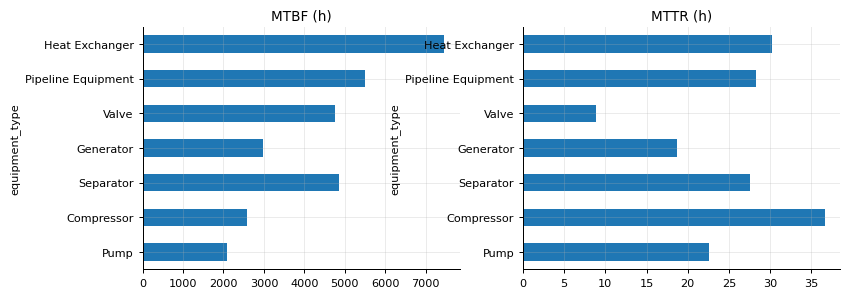

In [5]:
fig, ax = plt.subplots(1,2, figsize=(10,3.5)); bt.plot.barh(x="equipment_type", y="mtbf_hours", ax=ax[0], legend=False, title="MTBF (h)"); bt.plot.barh(x="equipment_type", y="mttr_hours", ax=ax[1], legend=False, title="MTTR (h)"); plt.show()

In [6]:
maintenance.critical_equipment(es)

   equipment_id     equipment_name equipment_type   field_id criticality  failures  total_downtime_hours  maintenance_cost_usd  mtbf_hours  mttr_hours  availability_pct  priority_score
17      EQ-0018  Compressor 002-06     Compressor  FIELD-002        High        12                631.86            372,856.56    2,139.34       43.43             97.60        1,895.58
4       EQ-0005  Compressor 001-05     Compressor  FIELD-001        High        11                518.26            350,545.17    2,344.16       36.03             98.03        1,554.78
5       EQ-0006  Compressor 001-06     Compressor  FIELD-001        High        10                513.47            351,927.69    2,579.05       38.92             98.05        1,540.41
29      EQ-0030  Compressor 003-06     Compressor  FIELD-003        High        10                506.12            441,367.05    2,579.79       41.54             98.08        1,518.36
38      EQ-0039        Pump 004-03           Pump  FIELD-004        High   

Priority score = criticality weight (High 3, Medium 2, Low 1) x total downtime hours.

In [7]:
eq = pd.read_csv(config.PROCESSED_DIR / "dim_equipment.csv"); maintenance.by_failure_type(maint, eq).head(10)

   equipment_type         failure_type  failures  downtime_hours  avg_downtime_hours   cost_usd
14           Pump        Impeller Wear        57        1,155.44               20.27 760,738.71
15           Pump    Motor Overheating        55        1,477.73               26.87 698,645.28
13           Pump      Bearing Failure        46          977.45               21.25 564,608.25
16           Pump            Seal Leak        41          880.69               21.48 567,682.13
1      Compressor          Overheating        22          861.93               39.18 698,867.52
3      Compressor        Valve Failure        22          828.35               37.65 547,640.66
2      Compressor            Seal Leak        20          708.54               35.43 430,023.27
4       Generator     Electrical Fault        17          270.79               15.93 148,625.24
18      Separator  Level Control Fault        16          450.95               28.18 305,597.66
0      Compressor  Excessive Vibration  

In [8]:
pareto = maintenance.cost_pareto(es); print("share of cost from top 10 units (%):", round(pareto.cum_share_pct.iloc[9],1)); maintenance.age_association(es)

share of cost from top 10 units (%): 36.4


            equipment_type  n_units  spearman_rho_age_vs_failures_per_year  p_value
0               Compressor        8                                  -0.40     0.33
1                     Pump       16                                   0.34     0.20
2                Separator        8                                   0.15     0.73
3  ALL (not type-adjusted)       48                                   0.22     0.13

Age-failure correlations are computed within equipment type; with 4-16 units per type the statistical power is low.